#**Projeto Chronos**
##CHALLENGE LOCAWEB 2026
Integrantes:

* Bruno Rosa - RM563779
* Danilo Alves - RM564109
* Enzo Cremaschi - RM562058
* Vinícius Macedo - RM561911

# 05 — Desafio 3: Risco de Violação de OLA/KPI (CatBoost) | Projeto Cronos

**Objetivo:** prever, no instante de abertura de um chamado, a probabilidade de violação do SLA/OLA (`KPI Violado?`), usando tudo que já validamos no projeto até aqui.

**Premissas utilizadas:**
- Vazamento: `gold_chamados_risco` já exclui `Resolvido`, `Encerrado`, `Duração`, `Código de fechamento`, `Solução` e `Status` — colunas que só existem depois do fechamento do chamado.
- Desbalanceamento: 0,97% de positivos (248 em ~25.600 chamados elegíveis) — usar `auto_class_weights='Balanced'`.
- Encoding de categóricas: o Ordered Target Statistics do CatBoost calcula isso dentro do próprio ajuste, usando só o treino de cada fold.
- Validação: walk-forward em janela expansiva, os mesmos 3 folds (mesmos limites de semana) usados no Desafio 1, agora aplicados por timestamp de chamado (`aplicar_fold_por_timestamp`).
- Métricas: PR-AUC como referência primária, Precision@K, intervalo de confiança por bootstrap.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer, generate_expanding_folds,
    flag_low_volume_groups, aplicar_fold_por_timestamp, treinar_catboost_fold,
    treinar_catboost_producao, otimizar_hiperparametros_catboost, avaliar_classificador_raro,
    calibrar_threshold_por_custo, bootstrap_metric_ci, precision_at_k, preparar_categoricas_catboost, salvar_modelo_catboost,
    checar_faixa_kpi, FAIXAS_VOLUME_ANUAL_P2, FAIXAS_VOLUME_ANUAL_P3,
    FAIXAS_OLA_QUEBRADO_ANUAL_P2, FAIXAS_OLA_QUEBRADO_ANUAL_P3,
)

logger = setup_logging('catboost_risco')


In [ ]:
!pip install catboost optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 18.5 MB/s eta 0:00:00


## 1. Carga da Gold

In [ ]:
gold_risco_path = PROJECT_PATHS.gold / 'gold_chamados_risco.parquet'
df = load_parquet_layer(gold_risco_path, logger=logger)
df['Aberto'] = pd.to_datetime(df['Aberto'])
logger.info('Carregado: %d chamados x %d colunas.', *df.shape)

logger.info('Distribuição de Prioridade na base completa:\n%s', df['Prioridade'].value_counts(dropna=False).to_string())
if '1 - Crítica' not in df['Prioridade'].unique():
    logger.warning("'1 - Crítica' não aparece na base — as metas oficiais de KPI (dicionário v2) também não têm faixa definida para essa prioridade, então isso é consistente, não um alerta de dado faltando.")


## 2. Filtro de elegibilidade + ajuste em `grupo_baixo_volume`

O alvo `KPI Violado?` só é definido para chamados com `Entrou para KPI? == 'SIM'` — o universo elegível é uma fatia da base total.

In [ ]:
df_elegivel = df[df['Entrou para KPI?'] == 'SIM'].copy()
df_elegivel['target'] = (df_elegivel['KPI Violado?'] == 'SIM').astype(int)

logger.info(
    'Universo elegível: %d chamados (%.1f%% da base total) | Positivos: %d (%.2f%%)',
    len(df_elegivel), len(df_elegivel) / len(df) * 100,
    df_elegivel['target'].sum(), df_elegivel['target'].mean() * 100,
)

2026-08-26 00:03:41 | INFO     | catboost_risco | Universo elegível: 25156 chamados (20.7% da base total) | Positivos: 238 (0.95%)


INFO:catboost_risco:Universo elegível: 25156 chamados (20.7% da base total) | Positivos: 238 (0.95%)


### 2.1 Validação cruzada com as metas oficiais de KPI

In [ ]:

volume_p2 = int((df_elegivel['Prioridade'] == '2 - Alta').sum())
volume_p3 = int((df_elegivel['Prioridade'] == '3 - Média').sum())
ola_quebrado_p2 = int(((df_elegivel['Prioridade'] == '2 - Alta') & (df_elegivel['target'] == 1)).sum())
ola_quebrado_p3 = int(((df_elegivel['Prioridade'] == '3 - Média') & (df_elegivel['target'] == 1)).sum())

logger.info('Volume elegível P2 = %d -> %s%% de atingimento', volume_p2, checar_faixa_kpi(volume_p2, FAIXAS_VOLUME_ANUAL_P2))
logger.info('Volume elegível P3 = %d -> %s%% de atingimento', volume_p3, checar_faixa_kpi(volume_p3, FAIXAS_VOLUME_ANUAL_P3))
logger.info('OLA quebrado P2 = %d -> %s%% de atingimento', ola_quebrado_p2, checar_faixa_kpi(ola_quebrado_p2, FAIXAS_OLA_QUEBRADO_ANUAL_P2))
logger.info('OLA quebrado P3 = %d -> %s%% de atingimento', ola_quebrado_p3, checar_faixa_kpi(ola_quebrado_p3, FAIXAS_OLA_QUEBRADO_ANUAL_P3))

assert all(checar_faixa_kpi(v, f) is not None for v, f in [
    (volume_p2, FAIXAS_VOLUME_ANUAL_P2), (volume_p3, FAIXAS_VOLUME_ANUAL_P3),
    (ola_quebrado_p2, FAIXAS_OLA_QUEBRADO_ANUAL_P2), (ola_quebrado_p3, FAIXAS_OLA_QUEBRADO_ANUAL_P3),
]), 'Algum número caiu fora de todas as faixas oficiais — checar filtro de elegibilidade!'


In [ ]:
df_elegivel = df_elegivel.drop(columns=['grupo_baixo_volume'], errors='ignore')
df_elegivel['grupo_baixo_volume'] = flag_low_volume_groups(df_elegivel, 'Grupo designado', min_volume=100).astype(int)

logger.info(
    'grupo_baixo_volume corrigido: %.1f%% dos chamados elegíveis pertencem a uma equipe de baixo volume (<100 casos elegíveis).',
    df_elegivel['grupo_baixo_volume'].mean() * 100,
)
assert df_elegivel['grupo_baixo_volume'].mean() > 0, 'A correção deveria capturar pelo menos algumas equipes de baixo volume!'

pct_com_incidente_pai_no_elegivel = df_elegivel['tem_incidente_pai'].mean() * 100
logger.info('%% de chamados elegíveis com incidente pai preenchido (deveria ser ~0%%): %.2f%%', pct_com_incidente_pai_no_elegivel)
assert pct_com_incidente_pai_no_elegivel < 1.0, 'Regra oficial violada: Incidente Pai preenchido não deveria entrar no KPI!'

## 3. Definição de features

In [ ]:
CAT_FEATURES = ['Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Aberto por', 'turno_abertura']
TEXT_FEATURES = ['descricao_limpa']
NUM_FEATURES = [
    'flag_categorizado', 'fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado',
    'fora_horario_comercial', 'hora_sin', 'hora_cos', 'dow_sin', 'dow_cos',
    'descricao_n_tokens', 'descricao_contagem_historica', 'pressao_fila_7d',
    'ic_contagem_historica', 'ic_horas_desde_ultimo_chamado',
    'grupo_contagem_historica', 'grupo_chamados_ultima_hora', 'grupo_baixo_volume',
]

TIME_COL = 'Aberto'
TARGET_COL = 'target'
COLUNAS_MODELO = CAT_FEATURES + TEXT_FEATURES + NUM_FEATURES + [TARGET_COL, TIME_COL]

df_modelo = df_elegivel[COLUNAS_MODELO].copy()
logger.info('Features: %d categóricas, %d texto, %d numéricas/binárias.', len(CAT_FEATURES), len(TEXT_FEATURES), len(NUM_FEATURES))


In [ ]:
# Catboost não aceita NaN, transformação aplicada
df_modelo = preparar_categoricas_catboost(df_modelo, CAT_FEATURES, rotulo_ausente='Ausente')
logger.info('Categóricas preparadas para o CatBoost (NaN -> "Ausente" como string).')

2026-08-26 00:03:41 | INFO     | catboost_risco | Categóricas preparadas para o CatBoost (NaN -> "Ausente" como string).


INFO:catboost_risco:Categóricas preparadas para o CatBoost (NaN -> "Ausente" como string).


## 4. Folds walk-forward — mesmos limites de semana do Desafio 1

In [ ]:
folds = generate_expanding_folds(start_date=df_modelo[TIME_COL].min().strftime('%Y-%m-%d'), min_train_weeks=30, test_weeks=7, n_folds=3)
for f in folds:
    df_tr, df_te = aplicar_fold_por_timestamp(df_modelo, TIME_COL, f)
    logger.info(
        'Fold %d: treino %s a %s (%d chamados, %d positivos) | teste %s a %s (%d chamados, %d positivos)',
        f['fold'], f['train_start'].date(), f['train_end'].date(), len(df_tr), df_tr[TARGET_COL].sum(),
        f['test_start'].date(), f['test_end'].date(), len(df_te), df_te[TARGET_COL].sum(),
    )

2026-08-26 00:03:41 | INFO     | catboost_risco | Fold 1: treino 2025-01-01 a 2025-07-29 (15040 chamados, 156 positivos) | teste 2025-07-30 a 2025-09-16 (3533 chamados, 23 positivos)


INFO:catboost_risco:Fold 1: treino 2025-01-01 a 2025-07-29 (15040 chamados, 156 positivos) | teste 2025-07-30 a 2025-09-16 (3533 chamados, 23 positivos)


2026-08-26 00:03:41 | INFO     | catboost_risco | Fold 2: treino 2025-01-01 a 2025-09-16 (18669 chamados, 181 positivos) | teste 2025-09-17 a 2025-11-04 (3445 chamados, 19 positivos)


INFO:catboost_risco:Fold 2: treino 2025-01-01 a 2025-09-16 (18669 chamados, 181 positivos) | teste 2025-09-17 a 2025-11-04 (3445 chamados, 19 positivos)


2026-08-26 00:03:41 | INFO     | catboost_risco | Fold 3: treino 2025-01-01 a 2025-11-04 (22224 chamados, 200 positivos) | teste 2025-11-05 a 2025-12-23 (2625 chamados, 34 positivos)


INFO:catboost_risco:Fold 3: treino 2025-01-01 a 2025-11-04 (22224 chamados, 200 positivos) | teste 2025-11-05 a 2025-12-23 (2625 chamados, 34 positivos)


## 5. Baseline — taxa histórica por Prioridade

Teste em baseline simples para prever a probabilidade de violação como a taxa histórica observada por `Prioridade`.

In [ ]:
def prever_baseline_taxa_prioridade(df_treino, df_teste, target_col='target'):
    taxa_por_prioridade = df_treino.groupby('Prioridade')[target_col].mean()
    taxa_global = df_treino[target_col].mean()
    return df_teste['Prioridade'].map(taxa_por_prioridade).fillna(taxa_global).values

## 6. Otimização de hiperparâmetros + treino + avaliação, por fold

A busca do Optuna acontece **estritamente dentro do treino de cada fold**.
O modelo final de cada fold é treinado com 100% do treino daquele fold, usando os hiperparâmetros vencedores.

In [ ]:
resultados_folds = {}

for f in folds:
    logger.info('=== Fold %d ===', f['fold'])
    df_treino, df_teste = aplicar_fold_por_timestamp(df_modelo, TIME_COL, f)

    resultado_opt = otimizar_hiperparametros_catboost(
        df_treino, target_col=TARGET_COL, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES,
        time_col=TIME_COL, n_trials=25, frac_validacao=0.2,
    )
    logger.info('Fold %d: melhores hiperparâmetros = %s (PR-AUC validação interna = %.4f)',
                f['fold'], resultado_opt['melhores_params'], resultado_opt['melhor_pr_auc_validacao'])

    resultado_modelo = treinar_catboost_fold(
        df_treino, df_teste, target_col=TARGET_COL, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES,
        params=resultado_opt['melhores_params'], time_col=TIME_COL,
    )

    y_score_baseline = prever_baseline_taxa_prioridade(df_treino, df_teste, TARGET_COL)

    avaliacao_catboost = avaliar_classificador_raro(resultado_modelo['y_true'], resultado_modelo['y_score'], k_list=[10, 20, 50])
    avaliacao_baseline = avaliar_classificador_raro(resultado_modelo['y_true'], y_score_baseline, k_list=[10, 20, 50])

    resultados_folds[f['fold']] = {
        'modelo': resultado_modelo['modelo'], 'y_true': resultado_modelo['y_true'],
        'y_score_catboost': resultado_modelo['y_score'], 'y_score_baseline': y_score_baseline,
        'params': resultado_opt['melhores_params'],
        'avaliacao_catboost': avaliacao_catboost, 'avaliacao_baseline': avaliacao_baseline,
    }
    logger.info('Fold %d — CatBoost: PR-AUC=%.4f [%.4f, %.4f] | Baseline: PR-AUC=%.4f',
                f['fold'], avaliacao_catboost['pr_auc'], avaliacao_catboost['pr_auc_ic_inferior'],
                avaliacao_catboost['pr_auc_ic_superior'], avaliacao_baseline['pr_auc'])

2026-08-26 00:03:41 | INFO     | catboost_risco | === Fold 1 ===


INFO:catboost_risco:=== Fold 1 ===


2026-08-26 00:14:42 | INFO     | catboost_risco | Fold 1: melhores hiperparâmetros = {'iterations': 782, 'learning_rate': 0.029731759670794156, 'depth': 5, 'l2_leaf_reg': 1.0422259339479674} (PR-AUC validação interna = 0.0833)


INFO:catboost_risco:Fold 1: melhores hiperparâmetros = {'iterations': 782, 'learning_rate': 0.029731759670794156, 'depth': 5, 'l2_leaf_reg': 1.0422259339479674} (PR-AUC validação interna = 0.0833)


2026-08-26 00:17:01 | INFO     | catboost_risco | Fold 1 — CatBoost: PR-AUC=0.0818 [0.0212, 0.1802] | Baseline: PR-AUC=0.0068


...

INFO:catboost_risco:=== Fold 3 ===


2026-08-26 00:41:55 | INFO     | catboost_risco | Fold 3: melhores hiperparâmetros = {'iterations': 623, 'learning_rate': 0.07201384222159778, 'depth': 5, 'l2_leaf_reg': 1.301422856179375} (PR-AUC validação interna = 0.1916)


INFO:catboost_risco:Fold 3: melhores hiperparâmetros = {'iterations': 623, 'learning_rate': 0.07201384222159778, 'depth': 5, 'l2_leaf_reg': 1.301422856179375} (PR-AUC validação interna = 0.1916)


2026-08-26 00:44:18 | INFO     | catboost_risco | Fold 3 — CatBoost: PR-AUC=0.2402 [0.1212, 0.3692] | Baseline: PR-AUC=0.0140


INFO:catboost_risco:Fold 3 — CatBoost: PR-AUC=0.2402 [0.1212, 0.3692] | Baseline: PR-AUC=0.0140


## 7. Comparação consolidada — CatBoost vs. baseline, com variância entre folds

In [ ]:
linhas_comparacao = []
for fold_num, r in resultados_folds.items():
    for nome_modelo, avaliacao in [('catboost', r['avaliacao_catboost']), ('baseline_prioridade', r['avaliacao_baseline'])]:
        linhas_comparacao.append({
            'fold': fold_num, 'modelo': nome_modelo,
            'pr_auc': avaliacao['pr_auc'], 'pr_auc_ic_inferior': avaliacao['pr_auc_ic_inferior'],
            'pr_auc_ic_superior': avaliacao['pr_auc_ic_superior'], 'roc_auc_referencia': avaliacao['roc_auc_referencia'],
            'precision_at_10': avaliacao['precision_at_10'], 'precision_at_20': avaliacao['precision_at_20'],
            'n_positivos_teste': avaliacao['n_positivos'],
        })

df_comparacao = pd.DataFrame(linhas_comparacao)
df_comparacao

,fold,modelo,pr_auc,pr_auc_ic_inferior,pr_auc_ic_superior,roc_auc_referencia,precision_at_10,precision_at_20,n_positivos_teste
0,1,catboost,0.0818,0.0212,0.1802,0.8133,0.2,0.10,23
1,1,baseline_prioridade,0.0068,0.0045,0.0093,0.5227,0.0,0.00,23
2,2,catboost,0.1415,0.0227,0.2810,0.7468,0.2,0.15,19
3,2,baseline_prioridade,0.0055,0.0033,0.0077,0.5020,0.0,0.00,19
4,3,catboost,0.2402,0.1212,0.3692,0.7812,0.7,0.35,34
5,3,baseline_prioridade,0.0140,0.0103,0.0183,0.5370,0.0,0.00,34


In [ ]:
resumo_comparacao = df_comparacao.groupby('modelo')[['pr_auc', 'roc_auc_referencia', 'precision_at_10', 'precision_at_20']].agg(['mean', 'std']).round(4)
resumo_comparacao

pr_auc         roc_auc_referencia          \
                       mean     std               mean     std   
modelo                                                           
baseline_prioridade  0.0088  0.0046             0.5206  0.0176   
catboost             0.1545  0.0800             0.7804  0.0333   

                    precision_at_10         precision_at_20          
                               mean     std            mean     std  
modelo                                                               
baseline_prioridade          0.0000  0.0000             0.0  0.0000  
catboost                     0.3667  0.2887             0.2  0.1323

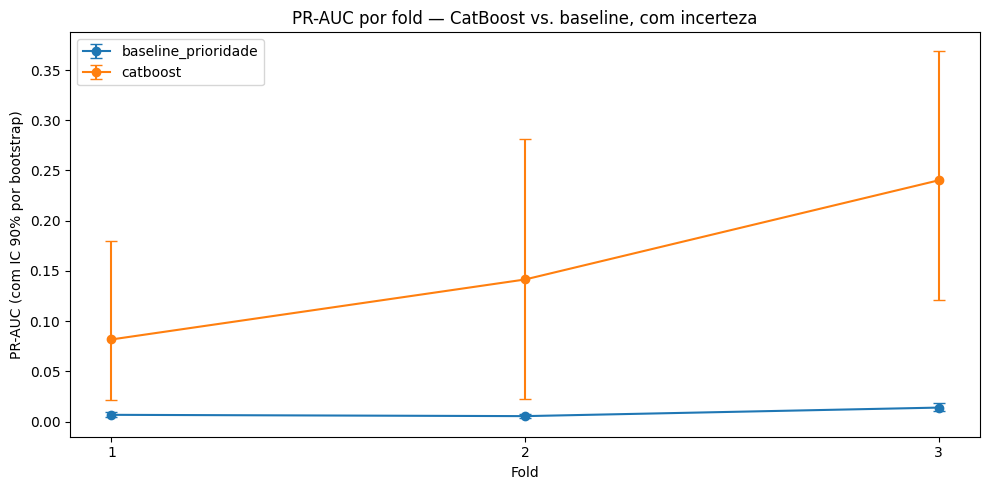

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for nome_modelo, grupo in df_comparacao.groupby('modelo'):
    ax.errorbar(
        grupo['fold'], grupo['pr_auc'],
        yerr=[grupo['pr_auc'] - grupo['pr_auc_ic_inferior'], grupo['pr_auc_ic_superior'] - grupo['pr_auc']],
        marker='o', capsize=4, label=nome_modelo,
    )
ax.set_xlabel('Fold')
ax.set_ylabel('PR-AUC (com IC 90% por bootstrap)')
ax.set_xticks([1, 2, 3])
ax.legend()
ax.set_title('PR-AUC por fold — CatBoost vs. baseline, com incerteza')
plt.tight_layout()
plt.show()

## 8. Calibração de threshold por custo de negócio

**Nota de escopo** os valores abaixo são **ilustrativos** (proporção 1:15, refletindo a intuição de que um SLA estourado custa mais caro que uma verificação extra).

In [ ]:
CUSTO_FALSO_POSITIVO_ILUSTRATIVO = 1
CUSTO_FALSO_NEGATIVO_ILUSTRATIVO = 15

f3 = folds[-1]
r3 = resultados_folds[3]
calibracao = calibrar_threshold_por_custo(
    r3['y_true'], r3['y_score_catboost'],
    custo_falso_positivo=CUSTO_FALSO_POSITIVO_ILUSTRATIVO, custo_falso_negativo=CUSTO_FALSO_NEGATIVO_ILUSTRATIVO,
)
logger.info('Calibração de threshold (fold 3, custo ilustrativo 1:15): %s', calibracao)

2026-08-26 00:44:18 | INFO     | catboost_risco | Calibração de threshold (fold 3, custo ilustrativo 1:15): {'threshold_otimo': 0.21484125233620904, 'precisao_no_threshold': 0.18032786885245902, 'recall_no_threshold': 0.3235294117647059, 'custo_esperado': 395.0}


INFO:catboost_risco:Calibração de threshold (fold 3, custo ilustrativo 1:15): {'threshold_otimo': 0.21484125233620904, 'precisao_no_threshold': 0.18032786885245902, 'recall_no_threshold': 0.3235294117647059, 'custo_esperado': 395.0}


## 9. Modelo de produção

Treinado com 100% do universo elegível disponível, usando os hiperparâmetros do fold mais recente (fold 3) como ponto de partida — é a configuração validada mais próxima do cenário real de implantação.

In [ ]:
modelo_producao = treinar_catboost_producao(
    df_modelo, target_col=TARGET_COL, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES,
    params=resultados_folds[3]['params'], time_col=TIME_COL,
)
logger.info('Modelo de produção treinado com %d chamados elegíveis (todo o histórico disponível).', len(df_modelo))

2026-08-26 00:46:47 | INFO     | catboost_risco | Modelo de produção treinado com 25156 chamados elegíveis (todo o histórico disponível).


INFO:catboost_risco:Modelo de produção treinado com 25156 chamados elegíveis (todo o histórico disponível).


## 10. Importância de features (nativa do CatBoost)

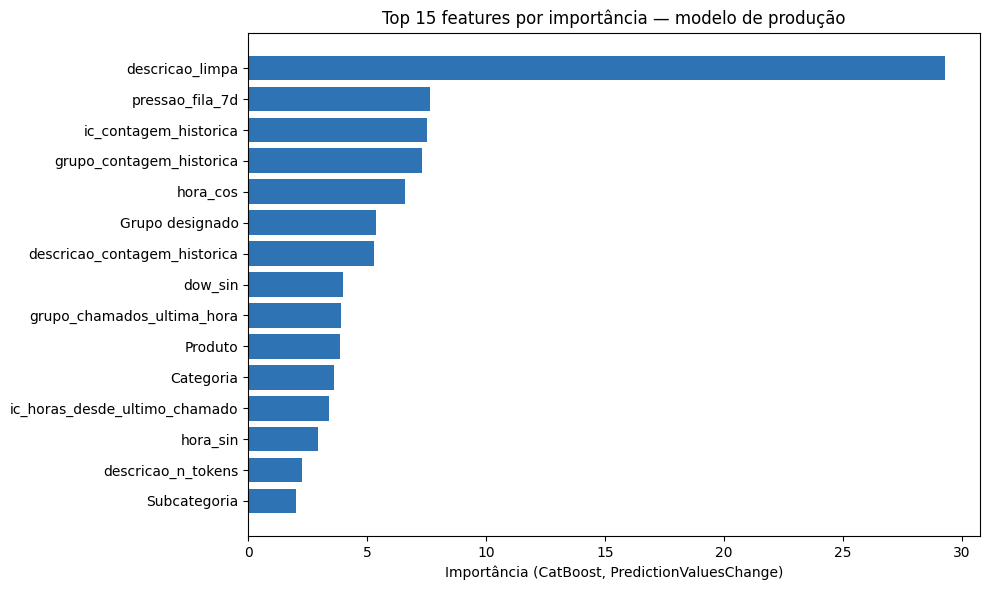

,feature,importancia
0,descricao_limpa,29.285250
1,pressao_fila_7d,7.654048
2,ic_contagem_historica,7.500380
3,grupo_contagem_historica,7.294364
4,hora_cos,6.599542
5,Grupo designado,5.366850
6,descricao_contagem_historica,5.264368
7,dow_sin,3.970704
8,grupo_chamados_ultima_hora,3.909195
9,Produto,3.850828


In [ ]:
importancias = modelo_producao.get_feature_importance(prettified=True)
importancias.columns = ['feature', 'importancia']
importancias = importancias.sort_values('importancia', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancias['feature'][::-1], importancias['importancia'][::-1], color='#2E74B5')
ax.set_xlabel('Importância (CatBoost, PredictionValuesChange)')
ax.set_title('Top 15 features por importância — modelo de produção')
plt.tight_layout()
plt.show()

importancias

## 11. Checagens de sanidade

In [ ]:
assert set(['Resolvido', 'Encerrado', 'Duração', 'Status']).isdisjoint(df_modelo.columns), 'Coluna de vazamento entrou no modelo!'
assert df_elegivel['grupo_baixo_volume'].mean() > 0, 'Correção do bug de grupo_baixo_volume não se sustentou!'
assert len(resultados_folds) == 3
for fold_num, r in resultados_folds.items():
    assert r['avaliacao_catboost']['n_positivos'] > 0, f'Fold {fold_num} sem nenhum positivo no teste!'
logger.info('Checagens de sanidade: OK.')

2026-08-26 00:46:47 | INFO     | catboost_risco | Checagens de sanidade: OK.


INFO:catboost_risco:Checagens de sanidade: OK.


## 12. Resumo de execução

In [ ]:
resumo_execucao = f'''
EXECUÇÃO DO MODELO CATBOOST (Desafio 3) — {pd.Timestamp.now(tz="UTC").isoformat()}
Universo elegível: {len(df_elegivel):,} chamados | Positivos: {df_elegivel["target"].sum()} ({df_elegivel["target"].mean()*100:.2f}%)

Comparação CatBoost vs. baseline (PR-AUC, média ± desvio-padrão entre folds):
{resumo_comparacao.to_string()}

Calibração de threshold (fold 3, custo ilustrativo 1:15): {calibracao}

Modelo de produção: treinado com {len(df_modelo):,} chamados elegíveis, hiperparâmetros do fold 3.
Top 3 features por importância: {importancias["feature"].head(3).tolist()}
'''.strip()

print(resumo_execucao)

EXECUÇÃO DO MODELO CATBOOST (Desafio 3) — 2026-08-26T00:46:47.308029+00:00
Universo elegível: 25,156 chamados | Positivos: 238 (0.95%)

Comparação CatBoost vs. baseline (PR-AUC, média ± desvio-padrão entre folds):
                     pr_auc         roc_auc_referencia         precision_at_10         precision_at_20        
                       mean     std               mean     std            mean     std            mean     std
modelo                                                                                                        
baseline_prioridade  0.0088  0.0046             0.5206  0.0176          0.0000  0.0000             0.0  0.0000
catboost             0.1545  0.0800             0.7804  0.0333          0.3667  0.2887             0.2  0.1323

Calibração de threshold (fold 3, custo ilustrativo 1:15): {'threshold_otimo': 0.21484125233620904, 'precisao_no_threshold': 0.18032786885245902, 'recall_no_threshold': 0.3235294117647059, 'custo_esperado': 395.0}

Modelo de produç

In [ ]:
caminho_modelo = salvar_modelo_catboost(modelo_producao, PROJECT_PATHS.gold / 'modelos' / 'catboost_producao.cbm')
logger.info('Modelo CatBoost salvo em: %s', caminho_modelo)

2026-08-26 00:46:47 | INFO     | catboost_risco | Modelo CatBoost salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/catboost_producao.cbm


INFO:catboost_risco:Modelo CatBoost salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/catboost_producao.cbm
